# Generating embeddings using TorchGeo

## 1. Dataset organization

### Downloading the CropHarvest dataset

In [1]:
from torchgeo.datasets import CropHarvest
from torchgeo.models import DOFABase16_Weights, DOFALarge16_Weights

RANDOM_STATE = 1998
ROOT = "_data"
OUTPUT_FOLDER = "_results/"
WEIGHTS = 'dofa_base_patch16_224'
WEIGHTS_NAME = DOFABase16_Weights.DOFA_MAE
# WEIGHTS = 'dofa_large_patch16_224'
# WEIGHTS_NAME = DOFALarge16_Weights.DOFA_MAE

original_dataset = CropHarvest(root=ROOT, download=False)

/Users/devseed/Documents/repos/embeddings_in_TorchGeo/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# pandas dataframe containing label data for everything on CropHarvest
original_dataset._load_labels(ROOT).head(5)

,type,properties.harvest_date,properties.planting_date,properties.label,properties.classification_label,properties.index,properties.is_crop,properties.lat,properties.lon,properties.dataset,properties.collection_date,properties.export_end_date,properties.externally_contributed_dataset,properties.is_test,geometry.type,geometry.coordinates,geometry
0,Feature,None,None,None,None,0,1,10.712596,37.083128,ethiopia,2020-10-22T00:00:00,2021-02-01T00:00:00,False,False,Polygon,"[[[37.0825205254332, 10.712735028397], [37.083...",NaN
1,Feature,None,None,None,None,1,1,10.724197,37.087377,ethiopia,2020-10-22T00:00:00,2021-02-01T00:00:00,False,False,Polygon,"[[[37.0872134731101, 10.7239755790256], [37.08...",NaN
2,Feature,None,None,None,None,2,1,10.713894,37.085091,ethiopia,2020-10-22T00:00:00,2021-02-01T00:00:00,False,False,Polygon,"[[[37.0849835772546, 10.7137105808623], [37.08...",NaN
3,Feature,None,None,None,None,3,1,10.713338,37.090290,ethiopia,2020-10-22T00:00:00,2021-02-01T00:00:00,False,False,Polygon,"[[[37.0902073888884, 10.7132048338664], [37.09...",NaN
4,Feature,None,None,None,None,4,1,10.721858,37.083121,ethiopia,2020-10-22T00:00:00,2021-02-01T00:00:00,False,False,Polygon,"[[[37.0830703114103, 10.7215953100434], [37.08...",NaN


### Exploring the dataset

In [3]:
# under properties.dataset we can find the names of the "sub datasets" inside CropHarvest
original_dataset_counts = original_dataset.labels['properties.dataset'].value_counts()

#  all the subdataset inside the CropHarvest dataset and the number of its samples
print("Sub-datasets inside CropHarvest:")
print(original_dataset_counts)

Sub-datasets inside CropHarvest:
properties.dataset
geowiki-landcover-2017          35866
croplands                       14976
canada                           9088
ile-de-france                    6184
central-asia                     5302
rwanda-ceo                       3600
reunion-france                   2776
kenya-non-crop                   2704
germany                          2550
martinique-france                2421
tanzania-ceo                     2400
mali-helmets-labelling-crops     1506
togo                             1276
lem-brazil                        860
ethiopia                          830
tanzania-rice-ecaas               800
sudan                             422
tanzania                          392
kenya                             319
togo-eval                         306
uganda                            233
mali                              148
mali-non-crop                     142
zimbabwe                           49
brazil-non-crop                    3

In [4]:
# group by the sub dataset name and look at the 'properties.label' column, which contains the crop type names
# if it is binary it will be None
# if it is multiclass it will have the crop type names

original_dataset_class_search = original_dataset.labels.groupby('properties.dataset')['properties.label'].unique()

binary = []
multiclass = []

for sub_dataset, labels in original_dataset_class_search.items():
    labels = [l for l in labels if l is not None and not (isinstance(l, float))]

    if len(labels) > 0:
        multiclass.append((sub_dataset, labels))
    else:
        binary.append(sub_dataset)

print("Binary sub-datasets:")
for i in binary:
    print(i)

print("\nMulticlass sub-datasets:")
for j in multiclass:
    print(j)

Binary sub-datasets:
brazil-non-crop
ethiopia
geowiki-landcover-2017
kenya-non-crop
mali-non-crop
rwanda-ceo
sudan
tanzania-ceo
togo
togo-eval

Multiclass sub-datasets:
('canada', ['wetland', 'abandoned (overgrown)', 'urban', 'shrubland', 'mixed forage', 'pasture (undiff)', 'sod', 'cereals (undiff)', 'barley (undiff)', 'corn', 'timothy', 'alfalfa', 'spring wheat', 'soybeans', 'forest', 'nursery', 'winter barley', 'canola/rapeseed', 'winter wheat', 'unimproved pasture', 'christmas trees', 'greenhouse', 'winter rye', 'pasture/forage', 'red clover', 'abandoned (shrubs)', 'other', 'fallow', 'native grassland', 'barren', 'water', 'oats', 'coniferous', 'white clover', 'broadleaf', 'clover (undiff)', 'sunflowers', 'greenfeed (mixed)', 'beans (undiff)', 'melon', 'apples', 'vegetables (undiff)', 'raspberry', 'fruits (berry & annual)', 'strawberry', 'onions', 'potatoes', 'broccoli', 'cauliflower', 'peas (undiff)', 'field peas', 'sugarbeets', 'ginseng', 'rye (undiff)', 'cherries', 'cucumber', 'to

## 2. *geowiki-landcover-2017* data exploration

### Isolate *geowiki-landcover-2017* sub dataset


We want to work with an isolated sub-set, binary, and preferably with lots of samples. For that reason it is wise to choose *geowiki-landcover-2017*
- **Sub dataset name:** *geowiki-landcover-2017*
- **Sample Count:** 35866 points
- **Format:** pixel-level time series

In [5]:
from torch.utils.data import Subset

# finding all the entries on original_dataset that has properties.dataset equal to 'geowiki-landcover-2017'
DATASET_NAME = 'central-asia'
central_asia_indices = original_dataset.labels.index[original_dataset.labels['properties.dataset'] == DATASET_NAME].tolist()

central_asia_dataset = Subset(original_dataset, central_asia_indices)

print(f"Original dataset size: {len(original_dataset)}")
print(f"Isolated dataset size: {len(central_asia_dataset)}")
print(f"Croplands indexes taken from the original dataset: {central_asia_indices}")

Original dataset size: 70213
Isolated dataset size: 5302
Croplands indexes taken from the original dataset: [39560, 39561, 39562, 39563, 39564, 39565, 39566, 39567, 39568, 39569, 39570, 39571, 39572, 39573, 39574, 39575, 39576, 39577, 39578, 39579, 39580, 39581, 39582, 39583, 39584, 39585, 39586, 39587, 39588, 39589, 39590, 39591, 39592, 39593, 39594, 39595, 39596, 39597, 39598, 39599, 39600, 39601, 39602, 39603, 39604, 39605, 39606, 39607, 39608, 39609, 39610, 39611, 39612, 39613, 39614, 39615, 39616, 39617, 39618, 39619, 39620, 39621, 39622, 39623, 39624, 39625, 39626, 39627, 39628, 39629, 39630, 39631, 39632, 39633, 39634, 39635, 39636, 39637, 39638, 39639, 39640, 39641, 39642, 39643, 39644, 39645, 39646, 39647, 39648, 39649, 39650, 39651, 39652, 39653, 39654, 39655, 39656, 39657, 39658, 39659, 39660, 39661, 39662, 39663, 39664, 39665, 39666, 39667, 39668, 39669, 39670, 39671, 39672, 39673, 39674, 39675, 39676, 39677, 39678, 39679, 39680, 39681, 39682, 39683, 39684, 39685, 39686, 39

In [6]:
# Access the original dataframe's classification_label for only the indices in your subset
unique_labels = original_dataset.labels.iloc[central_asia_indices]['properties.label'].unique()

print("Unique classification labels in your dataset:")
print(unique_labels)

# If you want to see the count for each (how many maize, how many wheat, etc.)
label_counts = original_dataset.labels.iloc[central_asia_indices]['properties.label'].value_counts()
print("\nCounts per label:")
print(label_counts)

Unique classification labels in your dataset:
['cotton' 'wheat' 'rice' 'orchard' 'alfalfa' 'maize' 'vineyard']

Counts per label:
properties.label
cotton      3277
wheat       1553
orchard      228
alfalfa       88
maize         65
vineyard      52
rice          39
Name: count, dtype: int64


### Data structure

Each data point represents a single geographic location over a full calendar year. Each sample is provided as a $12 \times 18$ tensor:
- Rows (12): Represent the 12 months of the year (temporal dimension)
- Columns (18): Represent the spectral and environmental bands (feature dimension)

The data combines multiple sensors and environmental variables:

| Band Index | Feature Category | Description |
| :--- | :--- | :--- |
| **0 - 12** | **Sentinel-2 (Optical)** | Multi-spectral bands including RGB, NIR, and Red-Edge |
| **13 - 14** | **Sentinel-1 (Radar)** | VV and VH polarizations (crucial for cloud-penetrating growth monitoring) |
| **15** | **ERA5 (Temp)** | 2-meter temperature data (average monthly) |
| **16** | **ERA5 (Precip)** | Total monthly precipitation |
| **17** | **SRTM (Elevation)** | Digital Elevation Model (Static value repeated across time steps) |

In [815]:
original_dataset.all_bands

('VV',
 'VH',
 'B2',
 'B3',
 'B4',
 'B5',
 'B6',
 'B7',
 'B8',
 'B8A',
 'B9',
 'B11',
 'B12',
 'temperature_2m',
 'total_precipitation',
 'elevation',
 'slope',
 'NDVI')

In [7]:
central_asia_dataset[7].keys()

dict_keys(['array', 'label'])

In [8]:
central_asia_dataset.__getitem__(45)['array'].shape

torch.Size([12, 18])

In [9]:
central_asia_dataset.__getitem__(45)['label']

tensor(1)

### Turning *geowiki-landcover-2017* into a binary dataset

But we can see that, after a careful look that not only the dataset label are not bianry but also they don't match with the classification labels `properties.is_crop`shown in the beginning. 

In [10]:
def investigation(subset, original, geowiki_indices, num_samples, y_array=None):
    label_map = {
        'cotton': 1,
        'wheat': 2,
        'orchard': 3,
        'alfalfa': 4,
        'maize': 5,
        'vineyard': 6,
        'rice': 7,
        None: 0  
    }
    header = f"{'Idx':<5} | {'Orig Idx':<8} | {'Wrapper':<8} | {'Meta (Str)':<12} | {'Embed Y':<8} | {'Status'}"
    print(header)
    print("-" * 80)

    for i in range(num_samples):
        label_my_dataset = int(subset[i]['label'])
        
        # Original string from metadata
        idx_original = geowiki_indices[i]
        meta_str = original.labels['properties.label'].iloc[idx_original]
        
        meta_int = label_map.get(meta_str, 0)
        
        y_val = y_array[i] if y_array is not None else "N/A"
        
        if label_my_dataset == meta_int:
            status = "ok"
        else:
            status = "!!MISMATCH!!"

        if y_array is not None and y_val != meta_int:
            status = "!!ARRAY SHIFT!!"

        print(f"{i:<5} | {idx_original:<8} | {label_my_dataset:<8} | {str(meta_str):<12} | {y_val:<8} | {status}")
    
    return

In [11]:
investigation(central_asia_dataset, original_dataset, central_asia_indices, 20)

Idx   | Orig Idx | Wrapper  | Meta (Str)   | Embed Y  | Status
--------------------------------------------------------------------------------
0     | 39560    | 1        | cotton       | N/A      | ok
1     | 39561    | 1        | cotton       | N/A      | ok
2     | 39562    | 1        | wheat        | N/A      | !!MISMATCH!!
3     | 39563    | 1        | cotton       | N/A      | ok
4     | 39564    | 0        | cotton       | N/A      | !!MISMATCH!!
5     | 39565    | 1        | cotton       | N/A      | ok
6     | 39566    | 0        | cotton       | N/A      | !!MISMATCH!!
7     | 39567    | 1        | cotton       | N/A      | ok
8     | 39568    | 1        | rice         | N/A      | !!MISMATCH!!
9     | 39569    | 250      | cotton       | N/A      | !!MISMATCH!!
10    | 39570    | 0        | orchard      | N/A      | !!MISMATCH!!
11    | 39571    | 74       | cotton       | N/A      | !!MISMATCH!!
12    | 39572    | 0        | cotton       | N/A      | !!MISMATCH!!
13    | 3

For this reason, we need to change the tensor label in each sample to match the metadata `properties.is_crop`.

|Label String | Integer ID|
|------------|-----------|
|None non_crop | 0|
cereals | 1
sugar|2
root_tuber|3
oilseeds|4
leguminous|5
other|6

In [12]:
import torch

class MultiClassDatasetWrapper(torch.utils.data.Dataset):
    def __init__(self, subset, original_dataset, bridge_indices):
        self.subset = subset
        # Direct access to the metadata table
        self.raw_labels = original_dataset.labels['properties.label']
        self.bridge_indices = bridge_indices
        
        self.label_map = {
            'cotton': 1,
            'wheat': 2,
            'orchard': 3,
            'alfalfa': 4,
            'maize': 5,
            'vineyard': 6,
            'rice': 7,
            None: 0  
        }

    def __getitem__(self, index):
        # 1. Get the original data (image/embeddings)
        original_sample = self.subset[index]
        
        # 2. Get the correct metadata index
        orig_idx = self.bridge_indices[index]
        label_str = self.raw_labels.iloc[orig_idx]
        
        # 3. Map the string to your 0-6 range
        class_id = self.label_map.get(label_str, 0)
        
        # 4. RECONSTRUCT the dictionary
        # This guarantees the old label (like 345) is deleted
        new_sample = {
            'array': original_sample['array'],      # Carry over the actual data
            'label': torch.tensor(class_id, dtype=torch.long), # Set the NEW label
            'label_name': str(label_str)            # Keep string for debugging
        }
        
        # If there are other keys like 'bbox' or 'crs', you can add them too:
        # new_sample.update({k: v for k, v in original_sample.items() if k not in ['image', 'label']})
        
        return new_sample

    def __len__(self):
        return len(self.subset)

In [13]:
dataset = MultiClassDatasetWrapper(central_asia_dataset, original_dataset, central_asia_indices)

In [14]:
investigation(dataset, original_dataset, central_asia_indices, 50)

Idx   | Orig Idx | Wrapper  | Meta (Str)   | Embed Y  | Status
--------------------------------------------------------------------------------
0     | 39560    | 1        | cotton       | N/A      | ok
1     | 39561    | 1        | cotton       | N/A      | ok
2     | 39562    | 2        | wheat        | N/A      | ok
3     | 39563    | 1        | cotton       | N/A      | ok
4     | 39564    | 1        | cotton       | N/A      | ok
5     | 39565    | 1        | cotton       | N/A      | ok
6     | 39566    | 1        | cotton       | N/A      | ok
7     | 39567    | 1        | cotton       | N/A      | ok
8     | 39568    | 7        | rice         | N/A      | ok
9     | 39569    | 1        | cotton       | N/A      | ok
10    | 39570    | 3        | orchard      | N/A      | ok
11    | 39571    | 1        | cotton       | N/A      | ok
12    | 39572    | 1        | cotton       | N/A      | ok
13    | 39573    | 3        | orchard      | N/A      | ok
14    | 39574    | 1        | 

### Data visualization

In [15]:
sample = dataset[0]
sample['label']

tensor(1)

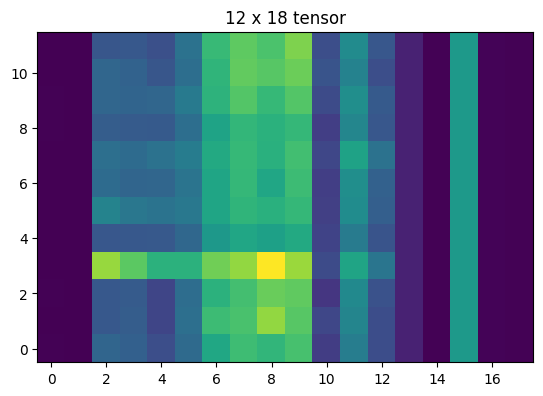

In [16]:
import matplotlib.pyplot as plt

# the actual tensor
plt.imshow(sample['array'], origin='lower')
plt.title("12 x 18 tensor")
plt.show()

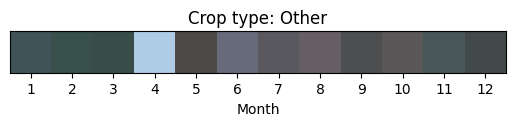

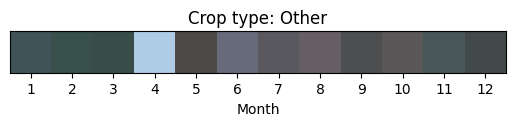

In [17]:
# it shows two plots because it is prepared to plot ground-truth and 
# it combines the rgb channels into a single pixel 
original_dataset.plot(sample)

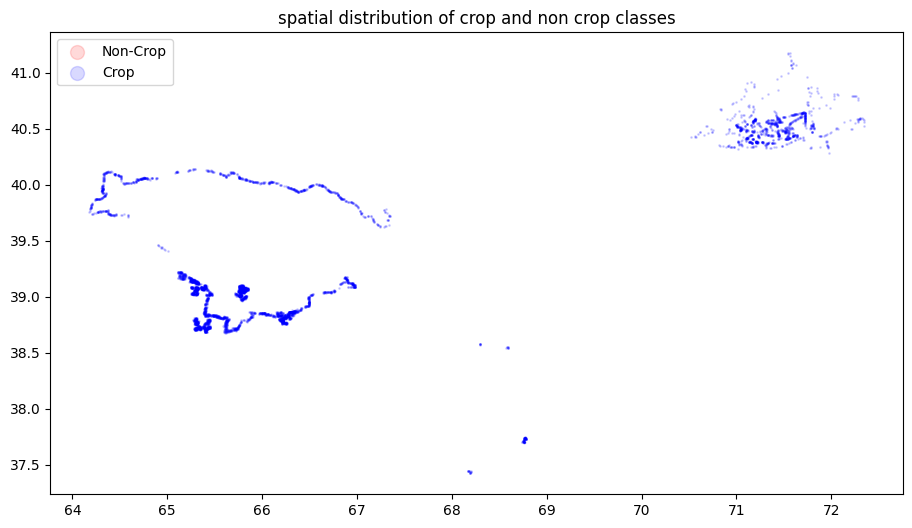

In [18]:
plt.figure(figsize=(11, 6))

geowiki_metadata = original_dataset.labels.iloc[central_asia_indices]

for is_crop, color, label in [(0, 'red', 'Non-Crop'), (1, 'blue', 'Crop')]:
    mask = geowiki_metadata['properties.is_crop'] == is_crop
    subset = geowiki_metadata[mask]
    plt.scatter(subset['properties.lon'], subset['properties.lat'], s=1, alpha=0.15, c=color, label=label)

plt.legend(markerscale=10)
plt.title("spatial distribution of crop and non crop classes")
plt.show()

## 3. Creating the embeddings model

### DOFA model

Instead of trying to retrain the whole DOFA model (which is huge and requires a lot of GPU memory), we will use DOFA as a "frozen" backbone to generate embeddings and train a simple, fast classifier on top.

In [19]:
import lightning as L
from torch.utils.data import DataLoader

class GeoWikiDataModule(L.LightningDataModule):
    def __init__(self, data, batch_size: int = 32, num_workers: int = 0):
        super().__init__()
        self.data = data
        self.batch_size = batch_size
        self.num_workers = num_workers

    def dataloader(self):
        return DataLoader(
            self.data, 
            batch_size=self.batch_size, 
            shuffle=False, 
            num_workers=self.num_workers
        )

In [20]:
# loading data
data_module = GeoWikiDataModule(dataset, batch_size=16, num_workers=0)
data_loader = data_module.dataloader()

In [21]:
# define device to use, cuda, cpu or mps (our case with mac)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps") # for mac users
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


In [22]:
from torchgeo.models import get_model

model = get_model(WEIGHTS, weights=WEIGHTS_NAME)
model = model.eval()

In [ ]:
# import torch.nn.functional as F
# import numpy as np
# from tqdm import tqdm

# def embeddings_dofa(model, dataloader, device):
#     model.eval()
#     model.to(device)
#     x_all, y_all = [] , []
    
#     wavelengths = [60.0, 60.0, 490.0, 560.0, 665.0, 842.0, 1610.0, 2190.0, 
#                    865.0, 705.0, 740.0, 783.0, 0.0, 0.0, 0.0, 0.0, 0.0, 490.0]

#     for batch in tqdm(dataloader):
#         x = batch['array'].to(torch.float32).to(device) 
#         y = batch['label']

#         # why doing this?!
#         x = x.permute(0, 2, 1) 
#         # and why doing this?!
#         x = x.unsqueeze(-1)
#         # also why doing this?!
#         x = F.pad(x, (0, 15, 0, 4)) 

#         with torch.inference_mode():
#             features = model.forward_features(x, wavelengths=wavelengths)
            
#             # why doing this?!
#             if features.ndim == 3:
#                 # why doing this?!
#                 embeddings = features.mean(dim=1) 
#             else:
#                 embeddings = features

#         x_all.append(embeddings.cpu().numpy())
#         y_all.append(y.numpy())

#     return np.concatenate(x_all, axis=0), np.concatenate(y_all, axis=0)

In [24]:
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm

def embeddings_dofa_final(model, dataloader, device):
    model.eval()
    model.to(device)
    x_all, y_all = [], []
    
    wavelengths = [60.0, 60.0, 490.0, 560.0, 665.0, 842.0, 1610.0, 2190.0, 
                   865.0, 705.0, 740.0, 783.0, 0.0, 0.0, 0.0, 0.0, 0.0, 490.0]

    for batch in tqdm(dataloader):
        # 1. Get raw data
        x = batch['array'].to(torch.float32).to(device) 
        y = batch['label']

        # 2. FORCE SHAPE: (Batch, 18 Channels, 1 Height, 1 Width)
        # -1 automatically calculates the batch size
        try:
            x = x.reshape(-1, 18, 1, 1).to(device) 
        except RuntimeError:
            # If the above fails, it means your 'array' doesn't have 18 elements.
            # Let's print the shape to see what's actually inside.
            print(f"CRITICAL ERROR: Shape is {x.shape}, expected 18 elements.")
            raise

        # 3. INTERPOLATE: Now it's a guaranteed 4D tensor (B, 18, 1, 1)
        # Mode 'nearest' is safer for 1x1 -> 224x224
        x = F.interpolate(x, size=(224, 224), mode='nearest').to(device) 

        with torch.inference_mode():
            features = model.forward_features(x, wavelengths=wavelengths)
            
            if features.ndim == 3:
                # Use CLS token (index 0)
                embeddings = features[:, 0, :] 
            else:
                embeddings = features

        x_all.append(embeddings.cpu().numpy())
        y_all.append(y.numpy())

    return np.concatenate(x_all, axis=0), np.concatenate(y_all, axis=0)

In [25]:
# ensure that is running on mps or chosen device
model = model.to(device) 

print("Extracting embeddings...")
x, y = embeddings_dofa_final(model, data_loader, device)

print(f"Done! Created {x.shape[0]} vectors of size {x.shape[1]}")

Extracting embeddings...


100%|██████████| 332/332 [1:13:58<00:00, 13.37s/it]

Done! Created 63624 vectors of size 768


In [26]:
# save the embeddings
# np.save(f'{OUTPUT_FOLDER}x_dofa-{WEIGHTS}.npy', x)
# np.save(f'{OUTPUT_FOLDER}y_dofa-{WEIGHTS}.npy', y)

# for new dataset
np.save(f'{OUTPUT_FOLDER}x_dofa-{WEIGHTS}-central_asia-multiclass.npy', x)
np.save(f'{OUTPUT_FOLDER}y_dofa-{WEIGHTS}-central_asia-multiclass.npy', y)

print("Files saved successfully!")

Files saved successfully!


### Sanity check

In [27]:
# load the embeddings in case you dont want to run the model again
# x = np.load(f'{OUTPUT_FOLDER}x_dofa-{WEIGHTS}.npy')
# y = np.load(f'{OUTPUT_FOLDER}y_dofa-{WEIGHTS}.npy')

# for new dataset
np.save(f'{OUTPUT_FOLDER}x_dofa-{WEIGHTS}-central_asia-multiclass.npy', x)
np.save(f'{OUTPUT_FOLDER}y_dofa-{WEIGHTS}-central_asia-multiclass.npy', y)

print("Files loaded successfully!")

Files loaded successfully!


In [28]:
investigation(dataset, original_dataset, central_asia_indices, 20, y)

Idx   | Orig Idx | Wrapper  | Meta (Str)   | Embed Y  | Status
--------------------------------------------------------------------------------
0     | 39560    | 1        | cotton       | 1        | ok
1     | 39561    | 1        | cotton       | 1        | ok
2     | 39562    | 2        | wheat        | 2        | ok
3     | 39563    | 1        | cotton       | 1        | ok
4     | 39564    | 1        | cotton       | 1        | ok
5     | 39565    | 1        | cotton       | 1        | ok
6     | 39566    | 1        | cotton       | 1        | ok
7     | 39567    | 1        | cotton       | 1        | ok
8     | 39568    | 7        | rice         | 7        | ok
9     | 39569    | 1        | cotton       | 1        | ok
10    | 39570    | 3        | orchard      | 3        | ok
11    | 39571    | 1        | cotton       | 1        | ok
12    | 39572    | 1        | cotton       | 1        | ok
13    | 39573    | 3        | orchard      | 3        | ok
14    | 39574    | 1        | 

## Analysing the results

### Extracting lat and long 

Because the metadata will be lost after the train/test split (we'll lose the original indexes), it is necessary to save, at least, the latitude and longitude, following the same index order that the *geowiki-landcover-2017* dataset has.

In [29]:
import pandas as pd

def extract_coords(original_dataset, geowiki_indices):
    metadata_records = []
    raw_labels_df = original_dataset.labels 
    
    for i in range(len(geowiki_indices)):
        orig_idx = geowiki_indices[i]
        
        row = raw_labels_df.iloc[orig_idx]
        
        metadata_records.append({
            'subset_index': i,
            'original_index': orig_idx,
            'lat': row['properties.lat'],
            'lon': row['properties.lon'],
            #'label': int(row['properties.label']) # The verified label
        })
    
    return pd.DataFrame(metadata_records)

In [30]:
df_coords = extract_coords(original_dataset, central_asia_indices)
df_coords.head(20)

,subset_index,original_index,lat,lon
0,0,39560,40.426702,70.525842
1,1,39561,40.435171,70.559736
2,2,39562,40.431780,70.565671
3,3,39563,40.425288,70.574660
4,4,39564,40.452789,70.595566
5,5,39565,40.471184,70.614939
6,6,39566,40.471081,70.618419
7,7,39567,40.529850,70.677532
8,8,39568,40.528986,70.690011
9,9,39569,40.501811,70.735340


### Simple classifier

com labels erradas é 0.801

com labels certas é 0.547

In [31]:
len(x)

63624

In [32]:
len(y)

5302

In [33]:
len(df_coords)

5302

In [34]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test, meta_train, meta_test = train_test_split(
    x, 
    y, 
    df_coords,
    test_size=0.2, 
    random_state=RANDOM_STATE, 
    stratify=y
)

ValueError: Found input variables with inconsistent numbers of samples: [63624, 5302, 5302]

In [ ]:
# verify with random forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# training
rf = RandomForestClassifier(n_estimators=300, 
                            max_depth=20, 
                            min_samples_leaf=2, 
                            random_state=RANDOM_STATE)
rf.fit(x_train, y_train)

# predicting
y_pred = rf.predict(x_test)

# evaluating
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(classification_report(y_test, y_pred))

Random Forest Accuracy: 0.614
              precision    recall  f1-score   support

           1       0.62      0.97      0.76       656
           2       0.37      0.05      0.08       311
           3       0.00      0.00      0.00        46
           4       0.00      0.00      0.00        17
           5       0.00      0.00      0.00        13
           6       0.00      0.00      0.00        10
           7       0.00      0.00      0.00         8

    accuracy                           0.61      1061
   macro avg       0.14      0.15      0.12      1061
weighted avg       0.49      0.61      0.49      1061



/Users/devseed/Documents/repos/embeddings_in_TorchGeo/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/devseed/Documents/repos/embeddings_in_TorchGeo/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/devseed/Documents/repos/embeddings_in_TorchGeo/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` par

In [ ]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[637  19   0   0   0   0   0]
 [297  14   0   0   0   0   0]
 [ 42   4   0   0   0   0   0]
 [ 16   1   0   0   0   0   0]
 [ 13   0   0   0   0   0   0]
 [ 10   0   0   0   0   0   0]
 [  8   0   0   0   0   0   0]]


### Embeddings visualization

In [ ]:
np.unique_values(y)

array([1, 2, 3, 4, 5, 6, 7])

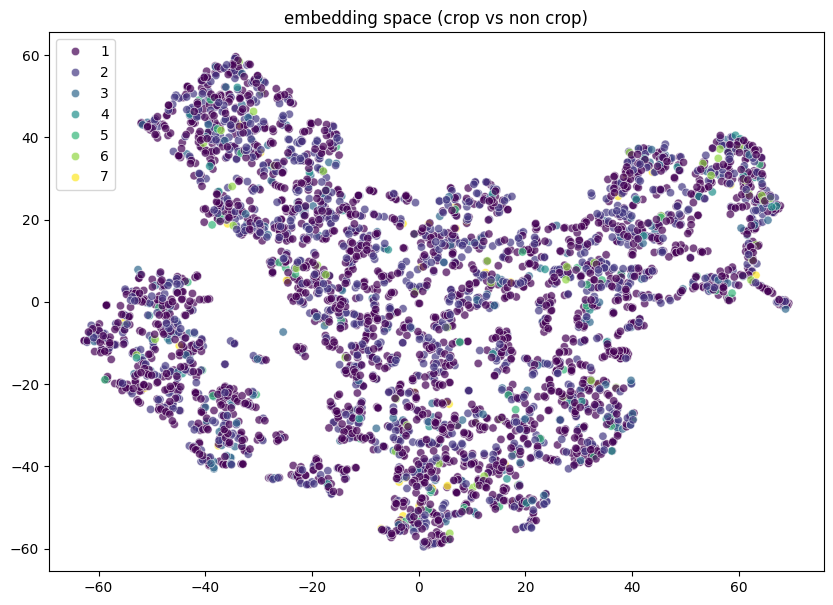

In [36]:
from sklearn.manifold import TSNE
import seaborn as sns

tsne = TSNE(n_components=2, random_state=RANDOM_STATE)
x_2d = tsne.fit_transform(x[:4000])
y = y[:4000]
plt.figure(figsize=(10, 7))
sns.scatterplot(x=x_2d[:,0], y=x_2d[:,1], hue=y, palette='viridis', alpha=0.7)
plt.title("embedding space (crop vs non crop)")
plt.show()

### Spatial correlation of the embeddings

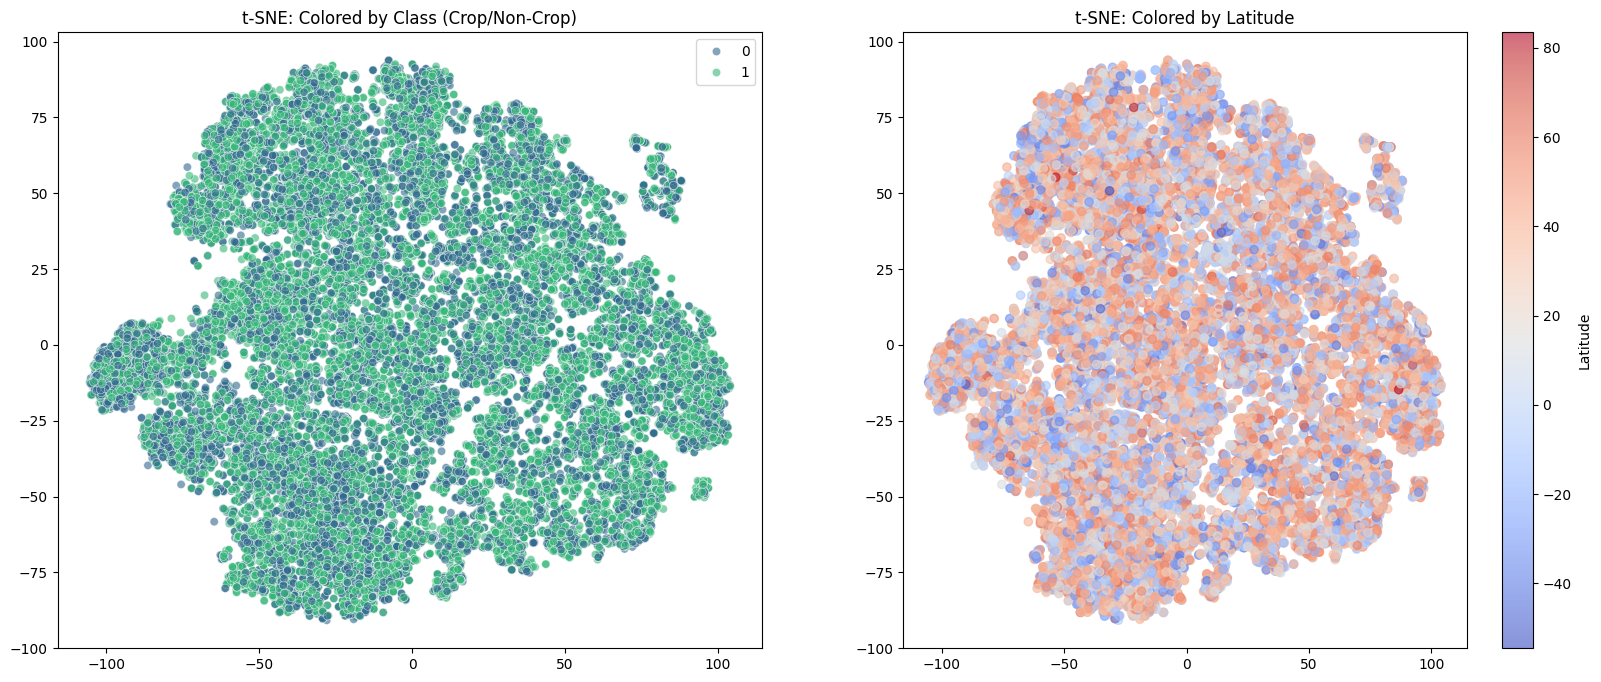

In [677]:
tsne = TSNE(n_components=2, random_state=42)
x_2d = tsne.fit_transform(x_train)

# 2. Plot side-by-side: One for Class, one for Geography
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Plot A: The Original (Crop vs Non-Crop)
sns.scatterplot(x=x_2d[:,0], y=x_2d[:,1], hue=y_train, palette='viridis', alpha=0.6, ax=ax1)
ax1.set_title("t-SNE: Colored by Class (Crop/Non-Crop)")

# Plot B: Colored by Latitude (using your meta_test or df_coords)
# Replace 'meta_test' with your master dataframe
scatter = ax2.scatter(x_2d[:,0], x_2d[:,1], c=meta_train['lat'], cmap='coolwarm', alpha=0.6)
fig.colorbar(scatter, ax=ax2, label='Latitude')
ax2.set_title("t-SNE: Colored by Latitude")

plt.show()

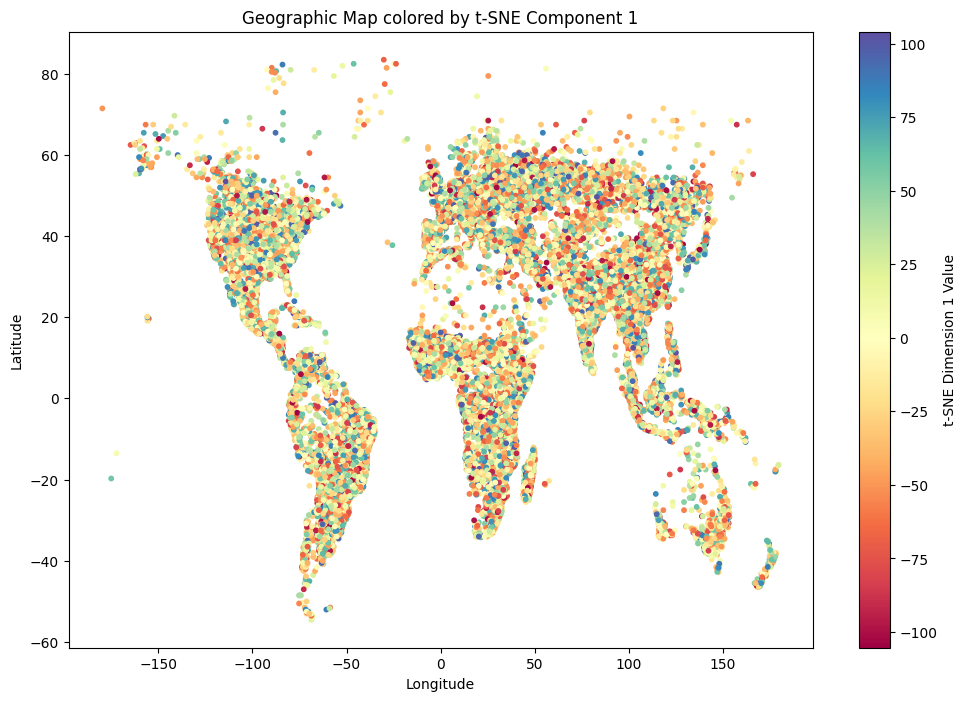

In [678]:
plt.figure(figsize=(12, 8))

# Here we plot actual Lat/Long but color by the t-SNE position
# We use x_2d[:,0] (the first t-SNE dimension) as the color
plt.scatter(meta_train['lon'], meta_train['lat'], c=x_2d[:,0], cmap='Spectral', s=10)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Map colored by t-SNE Component 1")
plt.colorbar(label="t-SNE Dimension 1 Value")
plt.show()